In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import snntorch as snn
import numpy as np

# --- 1. SNN (Original & Ablation) model ---
class Net(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs=2, num_steps=25, beta=0.95, thres=0.75):
        super().__init__()
        self.num_steps = num_steps
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, threshold=thres, learn_beta=False, learn_threshold=False)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, threshold=thres, learn_beta=False, learn_threshold=False)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        total_hidden_spikes = 0
        for step in range(self.num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            total_hidden_spikes += spk1.sum().item()
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
        return total_hidden_spikes

# --- 2. environment setting ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tasks = ['Intimacy', 'Empathy', 'Competition', 'High Focus']
neg_labels = ['non_Intimacy', 'non_Empathy', 'Cooperation', 'Low Focus']
thres_map = {'Intimacy': 0.75, 'Empathy': 0.75, 'Competition': 1.00, 'High Focus': 1.00}

ENERGY_MAC_PJ = 4.6
ENERGY_AC_PJ = 0.9
NUM_STEPS = 25

all_results = []

print("--- [심사 방어용] 공정 조건 기반 에너지 효율성 벤치마크 시작 ---")

# --- 3. energy efficiency evaluation ---
for pos_label, neg_label in zip(tasks, neg_labels):
    try:
        snn_x = torch.load(f"best_fold_data/{pos_label}_{neg_label}_x_val.pt", weights_only=True).to(device)
        num_samples = snn_x.size(0)
        in_features = snn_x.view(num_samples, -1).shape[1]
        
        # 1. FCN 
        macs_fcn_single = (in_features * 300) + (300 * 300) + (300 * 300) + (300 * 1)
        macs_fcn_total = macs_fcn_single * NUM_STEPS # 25 steps 동기화
        params_fcn = (in_features * 300 + 300) + (300 * 300 + 300) + (300 * 300 + 300) + (300 * 1 + 1)
        
        all_results.append({
            "Task": f"{pos_label}", "Model": "FCN (Baseline)",
            "Operations/Sample": f"{macs_fcn_total:,} MACs", 
            "Est. Energy (pJ)": macs_fcn_total * ENERGY_MAC_PJ,
            "Total Params": f"{params_fcn:,}"
        })
        
        # 2. FNN 
        macs_fnn_single = (in_features * 64) + (64 * 64) + (64 * 1)
        macs_fnn_total = macs_fnn_single * NUM_STEPS # 25 steps 동기화
        params_fnn = (in_features * 64 + 64) + (64 * 64 + 64) + (64 * 1 + 1)
        
        all_results.append({
            "Task": f"{pos_label}", "Model": "FNN (Baseline)",
            "Operations/Sample": f"{macs_fnn_total:,} MACs", 
            "Est. Energy (pJ)": macs_fnn_total * ENERGY_MAC_PJ,
            "Total Params": f"{params_fnn:,}"
        })
        
        # 3. SNN 
        snn_orig = Net(num_inputs=in_features, num_hidden=in_features, thres=thres_map[pos_label]).to(device)
        
        
        total_input_spikes = (snn_x.view(num_samples, -1) > 0).float().sum().item() * NUM_STEPS
        avg_input_spikes = total_input_spikes / num_samples
        
        with torch.no_grad():
            assumed_sparsity = 0.70
            
            avg_hidden_spikes_orig = (in_features * NUM_STEPS) * (1 - assumed_sparsity)
            sops_snn_orig = (avg_input_spikes * in_features) + (avg_hidden_spikes_orig * 2)
            params_snn_orig = sum(p.numel() for p in snn_orig.parameters())
            
            all_results.append({
                "Task": f"{pos_label}", "Model": "SNN (Original)",
                "Operations/Sample": f"{int(sops_snn_orig):,} SOPs", 
                "Est. Energy (pJ)": sops_snn_orig * ENERGY_AC_PJ,
                "Total Params": f"{params_snn_orig:,}"
            })
            

    except FileNotFoundError:
        pass



In [ ]:
# --- 4. print results ---
df_rebuttal = pd.DataFrame(all_results)
display(df_rebuttal)

## Visualizations

C:\Users\whd1g\AppData\Local\Temp\ipykernel_14484\3873590669.py:32: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_plot['Model'] = pd.Categorical(df_plot['Model'], categories=model_order, ordered=True)


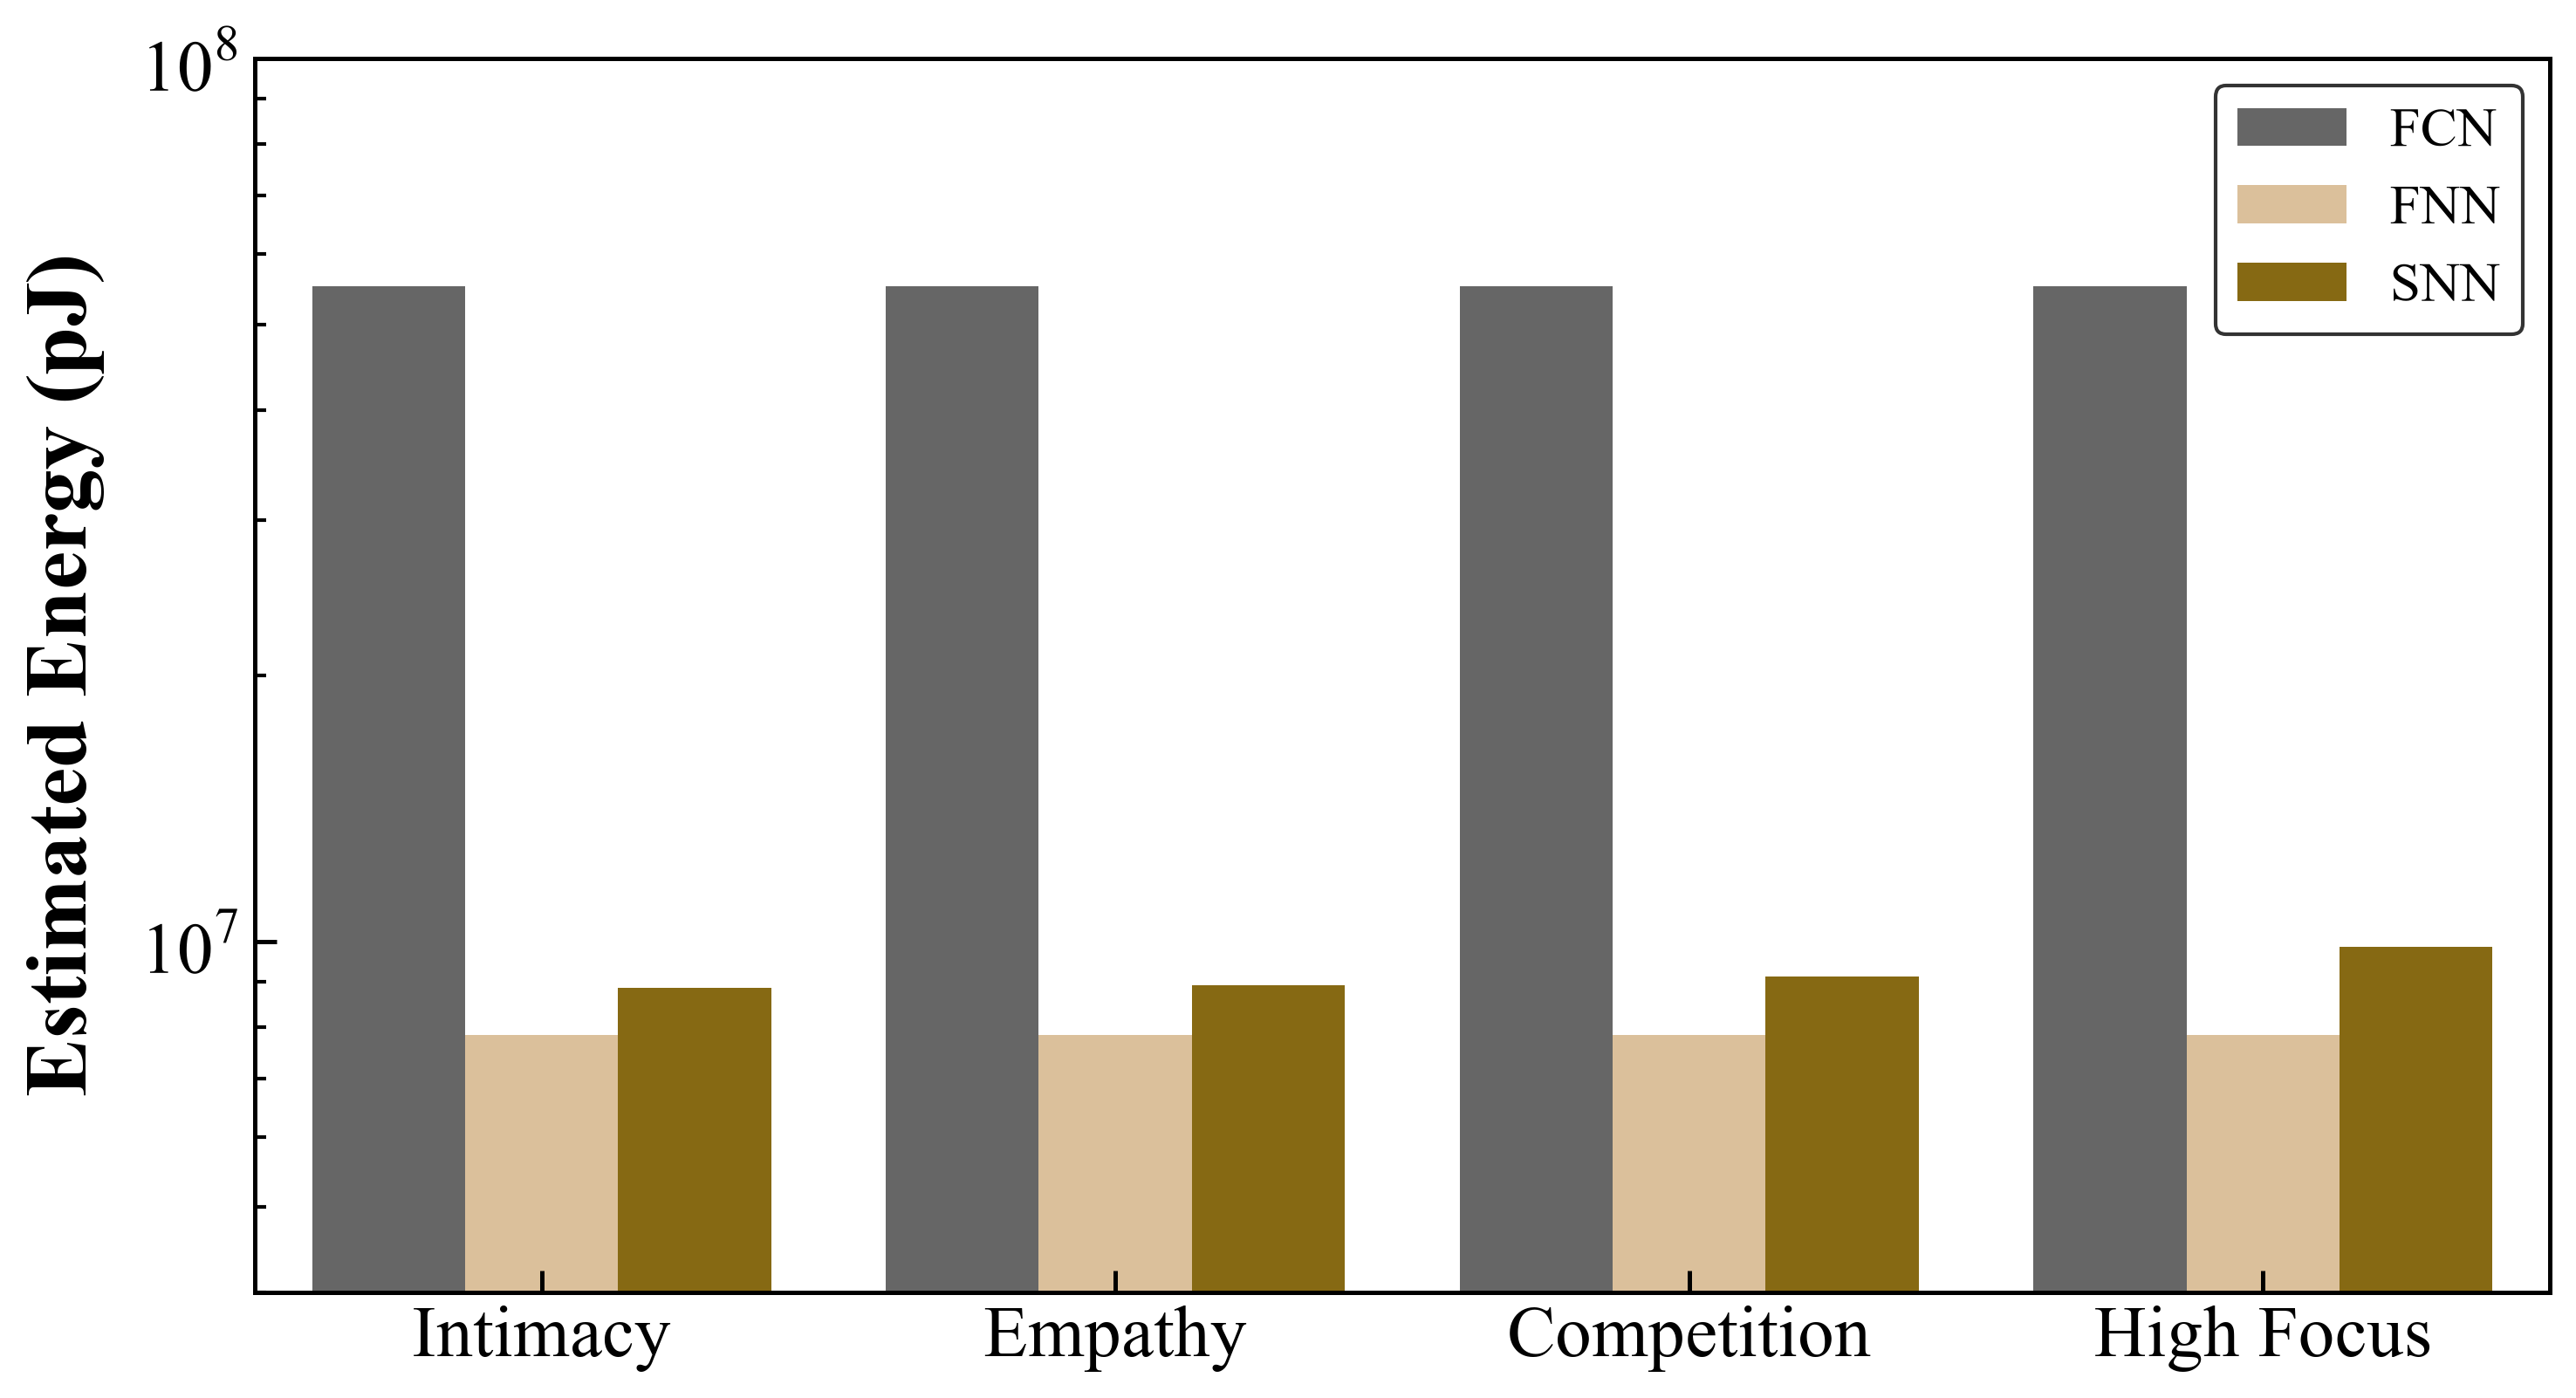

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif'] # 논문용 Serif 폰트
rcParams['axes.linewidth'] = 1.2
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 24
rcParams['axes.labelsize'] = 24
rcParams['xtick.labelsize'] = 20     
rcParams['ytick.labelsize'] = 20
rcParams['legend.fontsize'] = 15
rcParams['figure.dpi'] = 300


df_plot = df_rebuttal.copy()
df_plot['Energy'] = df_plot['Est. Energy (pJ)'].astype(float)


df_plot['Model'] = df_plot['Model'].replace({
    'FCN (Baseline)': 'FCN', 
    'FNN (Baseline)': 'FNN', 
    'SNN (Original)': 'SNN'
})

model_order = ['FCN', 'FNN', 'SNN']
df_plot['Model'] = pd.Categorical(df_plot['Model'], categories=model_order, ordered=True)

custom_palette = [ '#666666', '#E6C290', '#997300'] 

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(x='Task', y='Energy', hue='Model', data=df_plot, 
            palette=custom_palette, edgecolor='none', ax=ax)

ax.set_yscale('log')

ax.set_ylim(bottom=4e6, top=1e8)

ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
ax.tick_params(axis='y', which='minor', direction='in', length=3, width=1.0)

ax.set_ylabel('Estimated Energy (pJ)', fontweight='bold', labelpad=10)
ax.set_xlabel('') # X축 'Task' 글자는 직관적이므로 생략하여 깔끔하게 처리

legend = ax.legend(title='', loc='upper right', bbox_to_anchor=(1.0, 1.0), frameon=True)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1.0)

plt.tight_layout()
plt.savefig('Estimated_Energy_by_Task.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [31]:
df_plot

,Task,Model,Operations/Sample,Est. Energy (pJ),Total Params,Operations,Params
0,Intimacy,FCN,"12,007,500 MACs",5.523450e+07,"481,201",12007500.0,481201.0
1,Intimacy,FNN,"1,704,000 MACs",7.838400e+06,"68,289",1704000.0,68289.0
2,Intimacy,SNN,"9,844,530 SOPs",8.860078e+06,"1,003,002",9844530.0,1003002.0
4,Empathy,FCN,"12,007,500 MACs",5.523450e+07,"481,201",12007500.0,481201.0
5,Empathy,FNN,"1,704,000 MACs",7.838400e+06,"68,289",1704000.0,68289.0
6,Empathy,SNN,"9,904,325 SOPs",8.913893e+06,"1,003,002",9904325.0,1003002.0
8,Competition,FCN,"12,007,500 MACs",5.523450e+07,"481,201",12007500.0,481201.0
9,Competition,FNN,"1,704,000 MACs",7.838400e+06,"68,289",1704000.0,68289.0
10,Competition,SNN,"10,128,313 SOPs",9.115482e+06,"1,003,002",10128313.0,1003002.0
12,High Focus,FCN,"12,007,500 MACs",5.523450e+07,"481,201",12007500.0,481201.0


In [47]:
df_plot.to_csv("energy_consumption.csv", index=False)

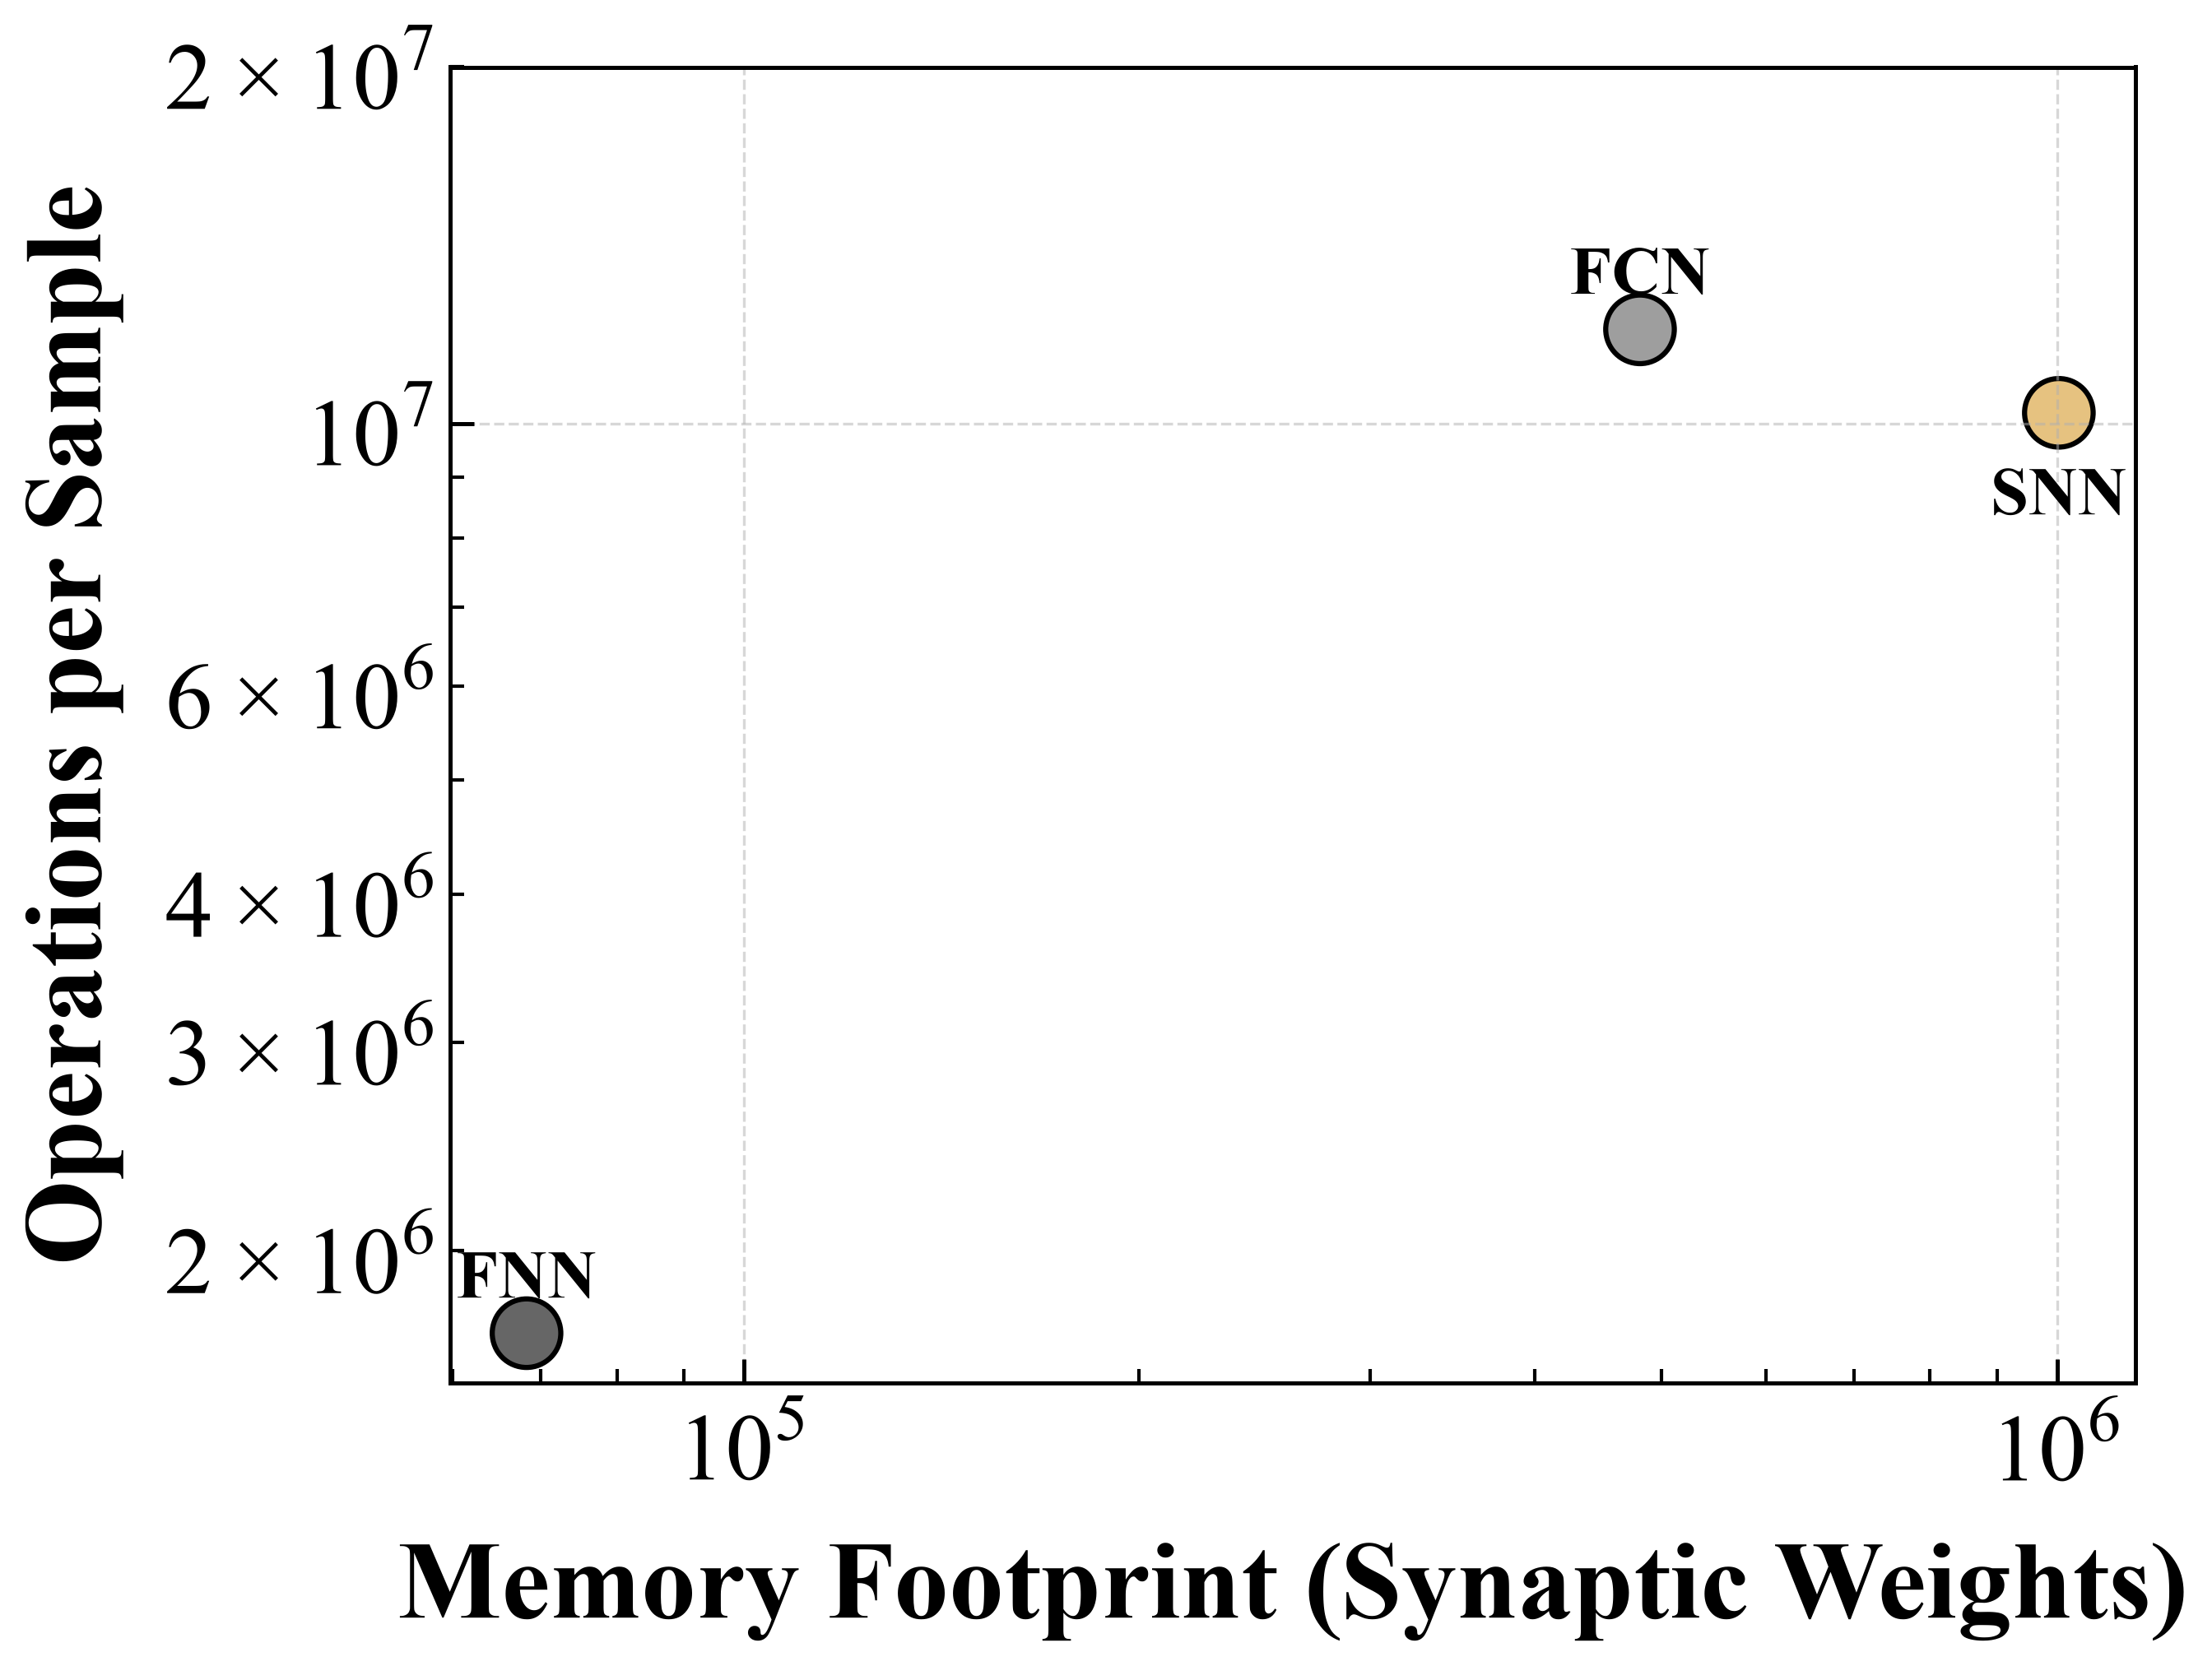

In [ ]:

from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['axes.linewidth'] = 1.2
rcParams['font.size'] = 15
rcParams['axes.titlesize'] = 32
rcParams['axes.labelsize'] = 32
rcParams['xtick.labelsize'] = 28     
rcParams['ytick.labelsize'] = 28
rcParams['figure.dpi'] = 300

df_plot = df_rebuttal.copy()
df_plot['Operations'] = df_plot['Operations/Sample'].str.replace(' MACs', '').str.replace(' SOPs', '').str.replace(',', '').astype(float)
df_plot['Params'] = df_plot['Total Params'].str.replace(',', '').astype(float)

df_plot['Model'] = df_plot['Model'].replace({
    'FCN (Baseline)': 'FCN', 
    'FNN (Baseline)': 'FNN', 
    'SNN (Original)': 'SNN'
})

df_plot = df_plot[df_plot['Model'].isin(['FCN', 'FNN', 'SNN'])]

df_mean = df_plot.groupby('Model')[['Params', 'Operations']].mean().reset_index()

model_order = ['FCN', 'FNN', 'SNN']
df_mean['Model'] = pd.Categorical(df_mean['Model'], categories=model_order, ordered=True)
df_mean = df_mean.sort_values('Model')

custom_palette = {'FCN': '#9E9E9E', 
                  'FNN': '#666666', 
                  'SNN': '#E6C280'}

fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(data=df_mean, x='Params', y='Operations', hue='Model', 
                s=400, palette=custom_palette, edgecolor='black', linewidth=1.5, ax=ax)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylim( top=2e7)


ax.tick_params(axis='both', which='major', direction='in', length=7, width=1.2)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0)

ax.set_xlabel('Memory Footprint (Synaptic Weights)', fontweight='bold', labelpad=12)
ax.set_ylabel('Operations per Sample', fontweight='bold', labelpad=12)

offsets = {
    'FCN': (0, 15),
    'FNN': (0, 15),
    'SNN': (0, -25)
}


for i in range(len(df_mean)):
    model_name = df_mean['Model'].iloc[i]
    ax.annotate(model_name, 
                (df_mean['Params'].iloc[i], df_mean['Operations'].iloc[i]),
                xytext=offsets[model_name], textcoords='offset points',
                ha='center', va='center', fontsize=20, fontweight='bold')


ax.grid(True, which="major", ls="--", alpha=0.5)

ax.get_legend().remove()

plt.tight_layout()
plt.savefig('SNN_Design_Space_Scatter_Revised.pdf', bbox_inches='tight', dpi=300)
plt.show()